In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

In [3]:

data = pd.read_csv('final_output_with_2012.csv')
data

,hours_previous_year,active_hours_previous_year,mmsi_count_previous_year,year,source_file,event_id,date,country,region,Location,...,IncomeClass_WGI,VAGov_WGI,PVGov_WGI,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF
0,NaN,NaN,NaN,1990,HOA_FDE_All_Final,e3154,7/18/1990,Somalia,Horn of Africa,Maydh Island,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.460
1,NaN,NaN,NaN,1990,HOA_FDE_All_Final,e2000,9/29/1990,Kenya,Horn of Africa,Kenyan Lake Victoria Waters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.051
2,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e4086,4/20/1991,Yemen,Horn of Africa,Yemeni waters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,30000.0,NaN
3,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e2003,6/1/1991,Kenya,Horn of Africa,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2700000.0,0.346
4,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e5006,6/1/1991,Yemen,Horn of Africa,yemeni coast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,30000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,6.830387e+06,5.390027e+06,1382.0,2023,Oceania_No_AUS_NZL_Final,52223449994,10/31/2023,Samoa,Oceania,Fagaalu Marine Protected Area.,...,Upper middle income,75.617571,87.135763,59.498392,52.185701,75.088207,64.429976,0.0,0.0,0.915
1052,6.582953e+06,5.535860e+06,1115.0,2019,Oceania_No_AUS_NZL_Final,53225464993,3/1/2024,Papua New Guinea,Oceania,"New Ireland Province, Papua New Guinea, specif...",...,Lower middle income,55.544024,52.242829,37.209910,46.850980,44.674778,27.873945,2.0,350.0,0.575
1053,6.044811e+06,4.733928e+06,1289.0,2024,Oceania_No_AUS_NZL_Final,54214315906,7/4/2024,French Polynesia,Oceania,"Tautira municipality, French Polynesia.",...,High income,72.191156,83.494244,NaN,NaN,74.471348,43.633725,0.0,0.0,0.895
1054,6.044811e+06,4.733928e+06,1289.0,2024,Oceania_No_AUS_NZL_Final,54501479045,8/6/2024,American Samoa,Oceania,"Vaitogi, American Samoa, specifically along th...",...,High income,73.136662,87.298125,66.261470,61.041225,75.665539,71.663617,0.0,0.0,1.588


In [4]:
print(data.shape)
df = data.loc[data['year'] >= 2012].copy()
#drop columns that are not needed for the model
df.drop(columns=['year','source_file','event_id','date','country','region','Location','latitude','longitude','loc_accuracy','Actor1','Actor2','ViolenceScore_Explanation','Explanation','Disputed','ForcedLabor','ECO_OHI','Summary'], inplace=True)
#drop rows with too many null values
#show the number of null values in each column
display(round(df.isnull().sum()/len(df)*100, 2))
# drop columns with more than 25% null values
df.drop(columns=['IncrPressure','LE_OHI','LIV_OHI'],inplace=True) #,'TR_OHI','GEGov_WGI','RGGov_WGI','NP_OHI','IncomeClass_WGI'
df.dropna(inplace=True)
print(df.shape)

(1056, 66)


hours_previous_year            0.00
active_hours_previous_year     0.00
mmsi_count_previous_year       0.00
WeakGov                        0.00
FishPop                        0.00
EcoChngeOther                  0.00
GroundsLim                     0.00
ForeignFisher                  0.00
IllegalFishing                 0.00
IncrEfficiency                 0.00
IncrPressure                  32.63
OpsScales                      0.00
Markets                        0.00
Poverty                        0.00
FoodInsecurity                 0.00
Marginalization                0.00
StratLoc                       0.00
MaritimeCrime                  0.00
violence_score                 0.00
WB_GDP                         5.36
AO_OHI                         2.33
BD_OHI                         1.86
CP_OHI                         1.86
CS_OHI                         3.03
CW_OHI                         1.86
FIS_OHI                        1.86
FOO_OHI                        1.86
HAB_OHI                     

(238, 45)


In [5]:
# join back summary column for embedding generation
df = df.join(data[['Summary']], how='left')

In [6]:
#scale data and handle categorical variables
df_x = df.drop(columns=['violence_score'])
df_y = df['violence_score']
display(df_x.head())

scaler = StandardScaler()

# separate Summary and categorical columns before scaling
df_x_summary = df_x[['Summary']]
cols_to_scale = df_x.drop(columns=['IncomeClass_WGI','Summary']).columns

# scale numeric columns (keep index)
df_x_scaled = pd.DataFrame(scaler.fit_transform(df_x[cols_to_scale]), columns=cols_to_scale, index=df_x.index)

# create dummies for IncomeClass_WGI with matching index
income_class_dummies = pd.get_dummies(df_x['IncomeClass_WGI'], drop_first=True, prefix='IncomeClass')
income_class_dummies.index = df_x.index

# create df with all input vars
df_x_scaled = pd.concat([df_x_scaled, income_class_dummies, df_x_summary], axis=1)
df_x_scaled

,hours_previous_year,active_hours_previous_year,mmsi_count_previous_year,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,...,VAGov_WGI,PVGov_WGI,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF,Summary
630,9.293813e+04,7.214843e+04,17.0,0,1,1,1,0,1,1,...,54.306201,63.766022,39.648453,47.215457,49.469864,35.336614,1.0,0.0,0.891,NaN
631,9.934829e+05,8.568749e+05,204.0,0,1,0,0,0,1,0,...,72.080065,92.665226,27.341918,38.144135,67.741392,44.285959,0.0,0.0,0.687,Fisheries and police officers have confiscated...
632,9.293813e+04,7.214843e+04,17.0,0,0,0,1,0,0,0,...,50.646769,40.388860,42.228777,46.784585,43.429425,28.120388,1.0,280670.0,0.981,NaN
633,1.832515e+07,1.004043e+07,5478.0,0,0,0,0,0,0,0,...,82.176045,84.569623,88.981136,82.123009,84.525671,85.114238,3.0,1500.0,2.161,"Russia banned the import of seal products, joi..."
634,1.832515e+07,1.004043e+07,5478.0,0,0,1,0,0,0,0,...,78.970213,76.497769,81.067472,77.609506,80.789015,73.421930,25.0,93551.0,1.458,Shell Oil filed a lawsuit against environmenta...


,hours_previous_year,active_hours_previous_year,mmsi_count_previous_year,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,...,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF,IncomeClass_Lower middle income,IncomeClass_Upper middle income,Summary
630,-0.704066,-0.795675,-0.708693,-0.600000,0.927025,2.043016,0.843937,-0.619452,1.034198,1.891276,...,-0.731457,-0.655101,-0.616601,-0.628485,-0.583811,-0.129468,-0.321265,True,False,NaN
631,-0.665901,-0.709916,-0.672211,-0.600000,0.927025,-0.489473,-1.184922,-0.619452,1.034198,-0.528744,...,-1.387234,-1.307754,0.568324,-0.170454,-0.669528,-0.129468,-0.766950,False,True,Fisheries and police officers have confiscated...
632,-0.704066,-0.795675,-0.708693,-0.600000,-1.078720,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,...,-0.593959,-0.686101,-1.008328,-0.997814,-0.583811,-0.093345,-0.124640,True,False,NaN
633,0.068617,0.293713,0.356704,-0.600000,-1.078720,-0.489473,-1.184922,-0.619452,-0.966933,-0.528744,...,1.897329,1.856389,1.656800,1.919154,-0.412377,-0.129275,2.453340,False,False,"Russia banned the import of seal products, joi..."
634,0.068617,0.293713,0.356704,-0.600000,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,-0.528744,...,1.475634,1.531656,1.414474,1.320737,1.473394,-0.117428,0.917476,False,False,Shell Oil filed a lawsuit against environmenta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,1.970863,1.581643,1.849938,-0.600000,0.927025,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,...,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False,The National Marine Fisheries Service (NMFS) h...
1044,-0.418532,-0.214508,-0.442392,-0.600000,-1.078720,-0.489473,0.843937,1.614330,1.034198,-0.528744,...,-1.231681,-0.911582,-0.700636,-0.611267,-0.669528,-0.129468,-0.699223,True,False,The Sanjaya 109 ship and its crew were detaine...
1049,1.970863,1.581643,1.849938,-0.600000,0.927025,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,...,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False,The National Marine Fisheries Service (NMFS) h...
1050,1.970863,1.581643,1.849938,1.666667,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,1.891276,...,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False,The Center for Biological Diversity has announ...


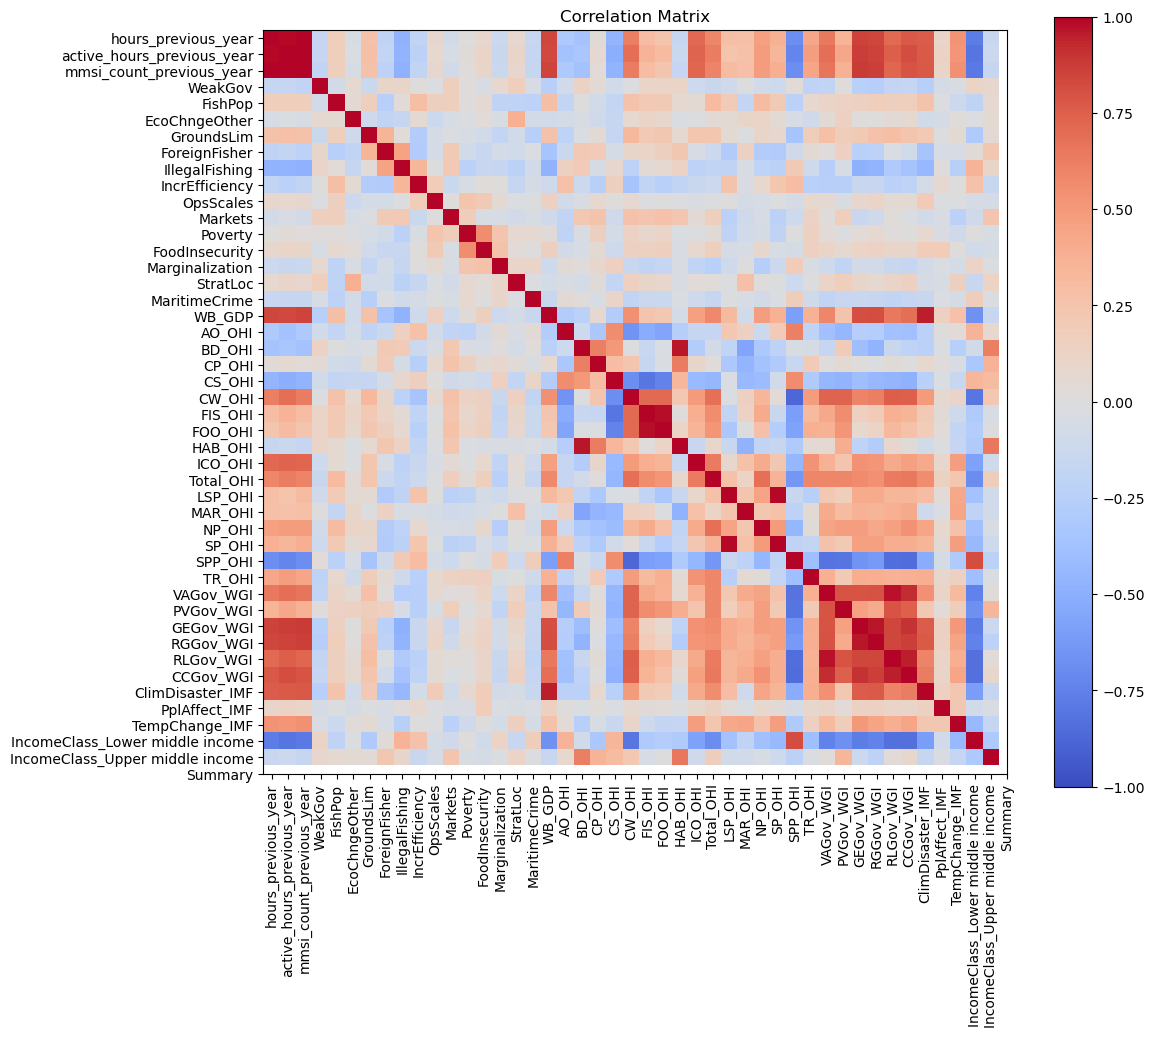

In [7]:
#check correlations in x variables (exclude summary column)
corr_matrix_x = df_x_scaled.drop(columns=['Summary']).corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix_x, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(df_x_scaled.columns)), df_x_scaled.columns, rotation=90)
plt.yticks(range(len(df_x_scaled.columns)), df_x_scaled.columns)
plt.show()

In [8]:
# load embedding model
# all-MiniLM-L6-v2 produces 384-dimensional vector for each summary
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# fill missing text with blank strings and generate embeddings
summaries = df['Summary'].fillna('').tolist()
print("Generating embeddings... This might take a moment.")
embeddings = embedder.encode(summaries)

# create a df of the embedding features with the same index as original df
embedding_cols = [f'emb_{i}' for i in range(embeddings.shape[1])]
embeddings_df = pd.DataFrame(embeddings, columns=embedding_cols, index=df.index)

# combine embeddings with scaled features df
x_with_embeddings = pd.concat([df_x_scaled, embeddings_df], axis=1)

# drop raw summary column
x_with_embeddings = x_with_embeddings.drop(columns=['Summary'], errors='ignore')

# final feature matrix with embeddings + scaled features
x_with_embeddings.head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings... This might take a moment.


,hours_previous_year,active_hours_previous_year,mmsi_count_previous_year,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
630,-0.704066,-0.795675,-0.708693,-0.6,0.927025,2.043016,0.843937,-0.619452,1.034198,1.891276,...,0.107304,0.011428,0.013367,-0.012747,0.061454,0.035641,0.158746,0.126410,0.046549,-0.015717
631,-0.665901,-0.709916,-0.672211,-0.6,0.927025,-0.489473,-1.184922,-0.619452,1.034198,-0.528744,...,-0.062107,0.042389,0.037935,-0.043329,-0.062384,0.086305,0.053131,-0.034719,0.058423,0.010837
632,-0.704066,-0.795675,-0.708693,-0.6,-1.078720,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,...,0.107304,0.011428,0.013367,-0.012747,0.061454,0.035641,0.158746,0.126409,0.046549,-0.015717
633,0.068617,0.293713,0.356704,-0.6,-1.078720,-0.489473,-1.184922,-0.619452,-0.966933,-0.528744,...,-0.007859,0.009619,0.015147,-0.000652,-0.009830,-0.022103,-0.038518,-0.079965,0.079295,0.030208
634,0.068617,0.293713,0.356704,-0.6,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,-0.528744,...,-0.009662,-0.003285,0.017646,0.043136,-0.004934,-0.039860,-0.019717,-0.001951,0.055697,0.069271


PCA explained variance by number of components:
n_components=10: cumulative explained variance = 0.6763
n_components=25: cumulative explained variance = 0.8078
n_components=50: cumulative explained variance = 0.9161
n_components=100: cumulative explained variance = 0.9898
n_components=200: cumulative explained variance = 1.0000


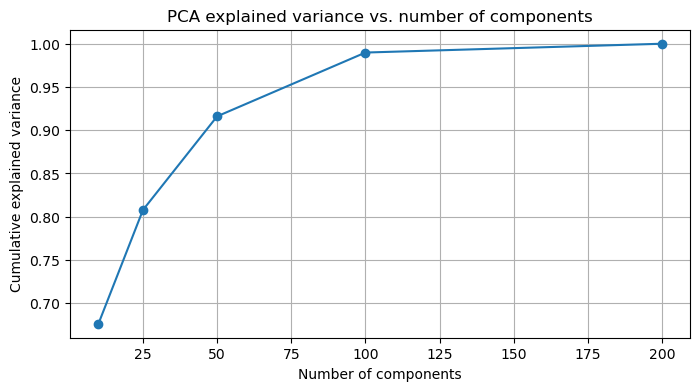

In [9]:
embedding_matrix = embeddings_df.to_numpy()

# determine number of pca components to test
n_components = [10, 25, 50, 100, 200]
results = []

# calculate cumulative explained variance for different numbers of pca components
for n in n_components:
    pca_temp = PCA(n_components = n, random_state=117)
    pca_temp.fit(embedding_matrix)
    cumulative_var = pca_temp.explained_variance_ratio_.sum()
    results.append((n, cumulative_var))

# printing explained variance by # components
print('PCA explained variance by number of components:')
for n, var in results:
    print(f'n_components={n}: cumulative explained variance = {var:.4f}')

# visualize results
plt.figure(figsize=(8, 4))
plt.plot([n for n, _ in results], [var for _, var in results], marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance vs. number of components')
plt.grid(True)
plt.show()

In [10]:


# perform pca on embedding cols to reduce dimensionality
# determined 50 components captures >90% of variance
pca = PCA(n_components=50, random_state=117)
pca_embeddings = pca.fit_transform(embeddings_df)

# create a df with pca embeddings
pca_cols = [f'pca_emb_{i}' for i in range(pca_embeddings.shape[1])]
pca_embeddings_df = pd.DataFrame(pca_embeddings, columns=pca_cols, index=embeddings_df.index)

pca_embeddings_df.head()

# combine the embeddings after pca applied to get new feature df
x_with_embeddings_pca = pd.concat([df_x_scaled, pca_embeddings_df], axis=1)
x_with_embeddings_pca.head()

,hours_previous_year,active_hours_previous_year,mmsi_count_previous_year,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,...,pca_emb_40,pca_emb_41,pca_emb_42,pca_emb_43,pca_emb_44,pca_emb_45,pca_emb_46,pca_emb_47,pca_emb_48,pca_emb_49
630,-0.704066,-0.795675,-0.708693,-0.6,0.927025,2.043016,0.843937,-0.619452,1.034198,1.891276,...,0.000130,0.000236,0.000194,0.000467,-0.000193,-0.000447,0.000723,-0.000562,-0.000245,0.000516
631,-0.665901,-0.709916,-0.672211,-0.6,0.927025,-0.489473,-1.184922,-0.619452,1.034198,-0.528744,...,-0.008190,-0.055981,-0.044735,0.062152,0.003972,0.012980,0.009833,-0.035127,0.060487,0.013698
632,-0.704066,-0.795675,-0.708693,-0.6,-1.078720,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,...,0.000130,0.000236,0.000194,0.000467,-0.000193,-0.000447,0.000723,-0.000562,-0.000245,0.000516
633,0.068617,0.293713,0.356704,-0.6,-1.078720,-0.489473,-1.184922,-0.619452,-0.966933,-0.528744,...,-0.029326,0.058818,-0.001831,0.019597,-0.077014,-0.028243,-0.035909,-0.035764,0.001639,0.058288
634,0.068617,0.293713,0.356704,-0.6,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,-0.528744,...,-0.006002,0.034302,-0.071895,-0.054331,-0.019251,-0.041921,-0.002333,-0.138576,0.031888,0.022316


In [17]:
# drop summary column before splitting into train/test sets
x_with_embeddings_pca = x_with_embeddings_pca.drop(columns=['Summary'], errors='ignore')

In [18]:
#split the data into training and testing sets
# use x with embeddings/pca for features and y for target variable
X_train, X_test, y_train, y_test = train_test_split(x_with_embeddings_pca, df_y, test_size=0.2, random_state=117)


In [19]:
#random forest model
rf = RandomForestClassifier(random_state=117,
                            n_estimators=100,                            
                            class_weight='balanced',
                            n_jobs=-1)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.625
              precision    recall  f1-score   support

           1       0.71      0.68      0.69        25
           2       0.50      0.59      0.54        17
           3       0.75      0.50      0.60         6

    accuracy                           0.62        48
   macro avg       0.65      0.59      0.61        48
weighted avg       0.64      0.62      0.63        48



In [20]:
#random forest model with grid search for hyperparameter tuning
grid_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,3,4,5],
    'min_samples_leaf': [1,2,3,4],
    'max_features': ['sqrt', 'log2']
}


rf_grid = GridSearchCV(RandomForestClassifier(random_state=117,
                                 class_weight='balanced'),
                                 grid_params,
                                 scoring='f1_macro',
                                 n_jobs=-1)

rf_grid.fit(X_train, y_train)
y_pred_grid = rf_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))
print("Best Parameters:", rf_grid.best_params_)


Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

           1       0.73      0.44      0.55        25
           2       0.41      0.71      0.52        17
           3       0.75      0.50      0.60         6

    accuracy                           0.54        48
   macro avg       0.63      0.55      0.56        48
weighted avg       0.62      0.54      0.55        48

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}


                            Feature    Importance
1        active_hours_previous_year  3.621895e-02
49                        pca_emb_4  2.560457e-02
2          mmsi_count_previous_year  2.551212e-02
26                          ICO_OHI  2.374566e-02
8                    IllegalFishing  2.213376e-02
..                              ...           ...
14                  Marginalization  1.911354e-03
11                          Markets  1.359197e-03
15                         StratLoc  1.332158e-03
13                   FoodInsecurity  2.582255e-04
44  IncomeClass_Upper middle income  5.920862e-19

[95 rows x 2 columns]


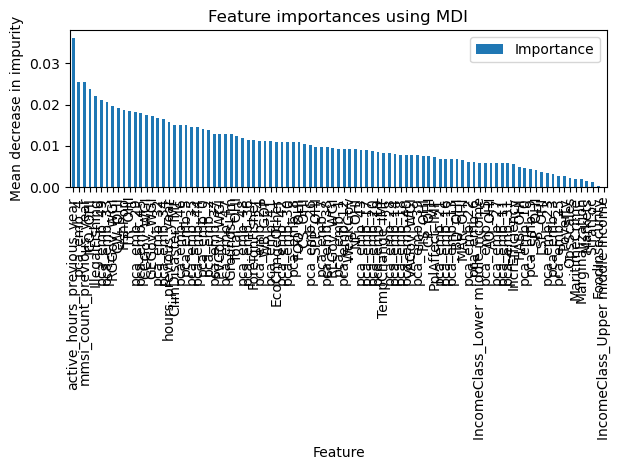

In [21]:
#get feature importances from the best model (GINI importance)
feature_importances = rf.feature_importances_
feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
print(feature_importances_df)

fig, ax = plt.subplots()
feature_importances_df.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

                       Feature  Importance
49                   pca_emb_4    0.125000
8               IllegalFishing    0.062500
1   active_hours_previous_year    0.062500
94                  pca_emb_49    0.062500
84                  pca_emb_39    0.062500
..                         ...         ...
82                  pca_emb_37    0.000000
92                  pca_emb_47    0.000000
88                  pca_emb_43    0.000000
3                      WeakGov   -0.020833
47                   pca_emb_2   -0.041667

[95 rows x 2 columns]


<Axes: xlabel='Feature'>

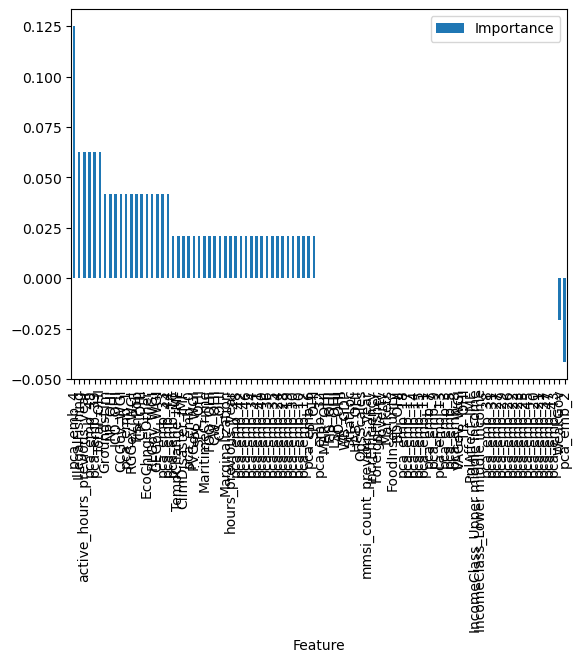

In [22]:
# calculate MDA
importances = []
initial_accuracy = accuracy_score(y_test, rf.predict(X_test))
for i in range(X_test.shape[1]):
    X_test_permuted = X_test.copy()
    permuted_values = X_test_permuted.iloc[:, i].to_numpy().copy()
    np.random.shuffle(permuted_values)
    X_test_permuted.iloc[:, i] = permuted_values
    permuted_accuracy = accuracy_score(y_test, rf.predict(X_test_permuted))
    importances.append(initial_accuracy - permuted_accuracy)

accuracy_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
accuracy_importances_df = accuracy_importances_df.sort_values(by='Importance', ascending=False)
print(accuracy_importances_df)

#plot
fig, ax = plt.subplots()
accuracy_importances_df.plot.bar(x='Feature', y='Importance', ax=ax)

                     Feature  Importance
27                 Total_OHI    0.064583
49                 pca_emb_4    0.060417
6                 GroundsLim    0.052083
26                   ICO_OHI    0.050000
84                pca_emb_39    0.047917
..                       ...         ...
17                    WB_GDP   -0.004167
33                    TR_OHI   -0.006250
76                pca_emb_31   -0.006250
2   mmsi_count_previous_year   -0.012500
3                    WeakGov   -0.016667

[95 rows x 2 columns]


<Axes: xlabel='Feature'>

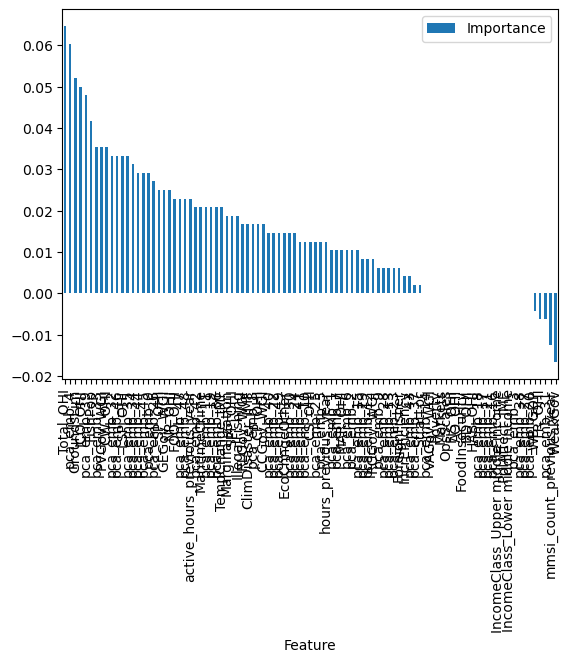

In [23]:
#permutation importance using sklearn's permutation_importance function
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=117,n_jobs=-1)
perm_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)
print(perm_importance_df)
#plot
fig, ax = plt.subplots()
perm_importance_df.plot.bar(x='Feature', y='Importance', ax=ax)


             Feature  Mean |SHAP Value|
3            WeakGov       3.335292e-02
25           HAB_OHI       3.123397e-02
24           FOO_OHI       2.751211e-02
4            FishPop       2.062243e-02
6         GroundsLim       2.043228e-02
..               ...                ...
47         pca_emb_2       3.798958e-04
50         pca_emb_5       2.450108e-04
41     PplAffect_IMF       4.923785e-05
39         CCGov_WGI       4.923785e-05
40  ClimDisaster_IMF       4.341044e-20

[95 rows x 2 columns]


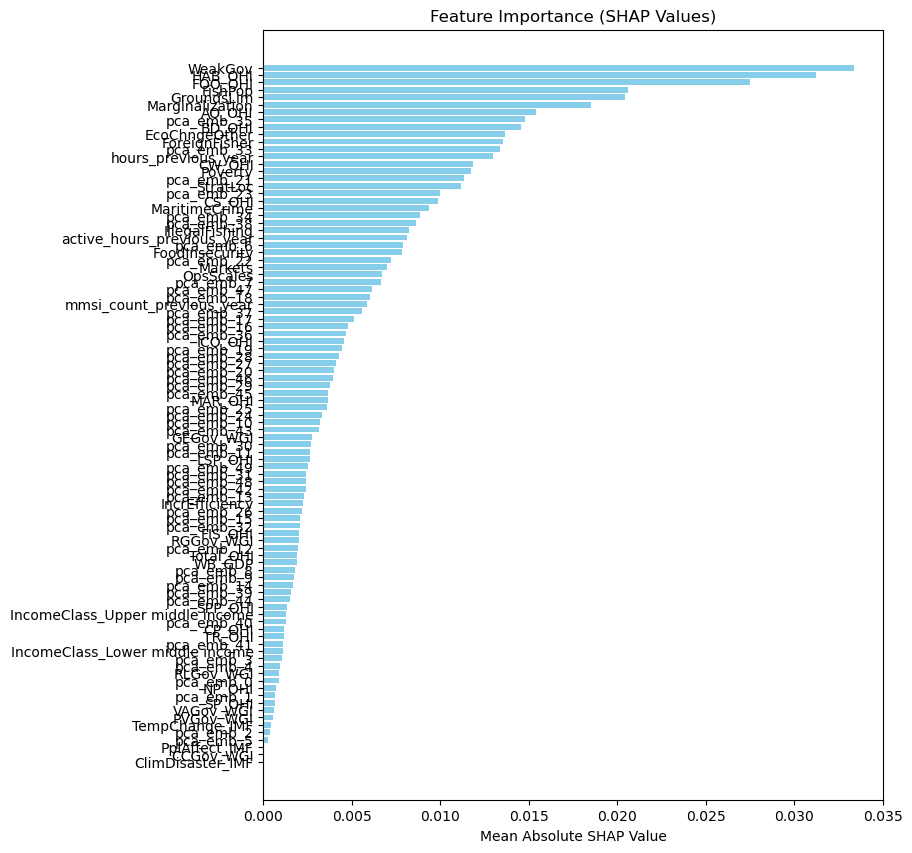

In [26]:
# calculate SHAP values
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_summary = np.mean(np.abs(np.stack(shap_values)), axis=(0, 1))
else:
    shap_summary = np.abs(shap_values).mean(axis=0)

shap_summary = shap_summary.flatten()
shap_summary = shap_summary[:len(x_with_embeddings_pca.columns)]  # Ensure the length matches the number of features
shap_summary_df = pd.DataFrame({
    'Feature': x_with_embeddings_pca.columns,
    'Mean |SHAP Value|': shap_summary
}).sort_values('Mean |SHAP Value|', ascending=False)

print(shap_summary_df)
plt.figure(figsize=(8, 10))
plt.barh(shap_summary_df['Feature'],
         shap_summary_df['Mean |SHAP Value|'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Feature Importance (SHAP Values)')
plt.gca().invert_yaxis()
plt.show()

In [27]:
#balanced random forest to handle class imbalance
rf_balanced_grid = GridSearchCV(BalancedRandomForestClassifier(random_state=117, n_jobs=-1),
                                grid_params,
                                scoring='f1_macro',
                                n_jobs=-1)
rf_balanced_grid.fit(X_train, y_train)
y_pred_balanced = rf_balanced_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
print("Best Parameters:", rf_balanced_grid.best_params_)



Accuracy: 0.5416666666666666
              precision    recall  f1-score   support

           1       0.73      0.44      0.55        25
           2       0.44      0.65      0.52        17
           3       0.50      0.67      0.57         6

    accuracy                           0.54        48
   macro avg       0.56      0.58      0.55        48
weighted avg       0.60      0.54      0.54        48

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [ ]:
#balanced bagging classifier to handle class imbalance
bagging_params = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]}

bagging_grid = GridSearchCV(BalancedBaggingClassifier(random_state=117),
                            bagging_params,
                            scoring='f1_macro',
                            n_jobs=-1)

bagging_grid.fit(X_train, y_train)
y_pred_bagging = bagging_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print(classification_report(y_test, y_pred_bagging))
print("Best Parameters:", bagging_grid.best_params_)

#bagging without grid search
bagging = BalancedBaggingClassifier(random_state=117,
                                     n_estimators=200,
                                     max_samples=0.75,
                                     max_features=0.75,
                                     bootstrap=True,
                                     bootstrap_features=True)
bagging.fit(X_train, y_train)
y_pred_bagging_no_grid = bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bagging_no_grid))
print(classification_report(y_test, y_pred_bagging_no_grid))


Accuracy: 0.5
              precision    recall  f1-score   support

           1       0.71      0.40      0.51        25
           2       0.38      0.59      0.47        17
           3       0.50      0.67      0.57         6

    accuracy                           0.50        48
   macro avg       0.53      0.55      0.52        48
weighted avg       0.57      0.50      0.50        48

Best Parameters: {'bootstrap': True, 'bootstrap_features': False, 'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 300}
Accuracy: 0.5208333333333334
              precision    recall  f1-score   support

           1       0.73      0.44      0.55        25
           2       0.42      0.59      0.49        17
           3       0.44      0.67      0.53         6

    accuracy                           0.52        48
   macro avg       0.53      0.56      0.52        48
weighted avg       0.59      0.52      0.53        48



In [29]:
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

# nltk downloads
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# load stemmer, lemmatizer, and stop words
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


# preprocess text function to clean/normalize text field
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# apply preprocessing to summary field
summary_text = df['Summary'].fillna('').astype(str)
processed_summaries = summary_text.apply(preprocess_text)

processed_summaries.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


630                                                     
631    fisheri polic offic confisc illeg shark produc...
632                                                     
633    russia ban import seal product join european u...
634    shell oil file lawsuit environment group nativ...
Name: Summary, dtype: object

In [31]:
# build tf-idf features from preprocessed summaries
vectorizer = TfidfVectorizer(ngram_range=(1, 2), 
                             min_df=2, 
                             max_df=0.95, 
                             sublinear_tf=True
                             )

X_text = vectorizer.fit_transform(processed_summaries)
print('TF-IDF feature shape:', X_text.shape)

# combine tf-idf features with structured features
from scipy.sparse import hstack, csr_matrix

structured_features = (
    df_x_scaled.drop(columns=['Summary'], errors='ignore')
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0.0)
    .astype(float)
)

structured_matrix = csr_matrix(structured_features.to_numpy())
X_text_with_structured = hstack([X_text, structured_matrix])
print('Combined feature shape:', X_text_with_structured.shape)

# split into train/test and evaluate rf model
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_text_with_structured,
    df_y,
    test_size=0.2,
    random_state=117,
    stratify=df_y
)

clf_tfidf = RandomForestClassifier(n_estimators=200,
                                   class_weight='balanced',
                                   random_state=117,
                                   n_jobs=-1
                                   )
clf_tfidf.fit(X_train_tfidf, y_train_tfidf)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

print('Accuracy:', accuracy_score(y_test_tfidf, y_pred_tfidf))
print(classification_report(y_test_tfidf, y_pred_tfidf))

TF-IDF feature shape: (238, 406)
Combined feature shape: (238, 451)
Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           1       0.69      0.77      0.73        26
           2       0.65      0.65      0.65        17
           3       0.50      0.20      0.29         5

    accuracy                           0.67        48
   macro avg       0.61      0.54      0.55        48
weighted avg       0.65      0.67      0.65        48



In [35]:
# extract model feature importances
feature_importances_tfidf = clf_tfidf.feature_importances_

# get feature names from vectorizer
tfidf_feature_names = vectorizer.get_feature_names_out()

# combine feature names with structured feature names
structured_feature_names = structured_features.columns.tolist()

# print top 50 most important features
all_feature_names = np.concatenate([tfidf_feature_names, structured_feature_names])
top_50_indices = np.argsort(feature_importances_tfidf)[::-1][:50]
print('Top 50 most important features:')
for i in top_50_indices:
    print(f'{all_feature_names[i]}: {feature_importances_tfidf[i]}')

Top 50 most important features:
IllegalFishing: 0.04652137113603139
GroundsLim: 0.045637104742731964
EcoChngeOther: 0.03617193660536827
WeakGov: 0.03492687680197147
IncrEfficiency: 0.03385413302976447
FishPop: 0.030882152062016496
WB_GDP: 0.02477363495775432
ForeignFisher: 0.023690252240043525
TR_OHI: 0.023271868029837765
hours_previous_year: 0.02040833324263264
MaritimeCrime: 0.02022823214523011
ICO_OHI: 0.02019454471794965
mmsi_count_previous_year: 0.01939214830775932
Total_OHI: 0.01933972255899112
GEGov_WGI: 0.019297084560294095
ClimDisaster_IMF: 0.019262014461347537
active_hours_previous_year: 0.019022560274581005
FIS_OHI: 0.01859311385199725
SPP_OHI: 0.018590192110497193
Marginalization: 0.0178031067470137
CW_OHI: 0.01777287914844992
CCGov_WGI: 0.01760263631838852
FOO_OHI: 0.017293516834138753
Poverty: 0.01701243890378169
PVGov_WGI: 0.01674476285917713
RLGov_WGI: 0.016077283764003178
LSP_OHI: 0.015852471133481004
RGGov_WGI: 0.0148984651532548
VAGov_WGI: 0.01444873040171488
SP_OHI: